<a href="https://colab.research.google.com/github/IdrisJunaidAI/efficacy-ai-learning-hub/blob/main/ITAI_1372_Panda101_IdrisJunaid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducing Pandas

Pandas is a Python library that makes handling tabular data easier. Since we're doing data science - this is something we'll use from time to time!

It's one of three libraries you'll encounter repeatedly in the field of data science:

## Pandas
Introduces "Data Frames" and "Series" that allow you to slice and dice rows and columns of information.

## NumPy
Usually you'll encounter "NumPy arrays", which are multi-dimensional array objects. It is easy to create a Pandas DataFrame from a NumPy array, and Pandas DataFrames can be cast as NumPy arrays. NumPy arrays are mainly important because of...

## Scikit_Learn
The machine learning library we'll use throughout this course is scikit_learn, or sklearn, and it generally takes NumPy arrays as its input.

So, a typical thing to do is to load, clean, and manipulate your input data using Pandas. Then convert your Pandas DataFrame into a NumPy array as it's being passed into some Scikit_Learn function. That conversion can often happen automatically.

Let's start by loading some comma-separated value data using Pandas into a DataFrame:


In [8]:
from google.colab import files

uploaded = files.upload()

import pandas as pd

df = pd.read_csv("PastHires.csv")
df.head()

Saving PastHires.csv to PastHires (2).csv


,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,Y,4,BS,N,N,Y
1,0,N,0,BS,Y,Y,Y
2,7,N,6,BS,N,N,N
3,2,Y,1,MS,Y,N,Y
4,20,N,2,PhD,Y,N,N


### Code Explanation
File Upload Explanation:
Google Colab runs in a temporary cloud environment, so local files from the computer are not automatically available to the notebook. This cell uploads the real PastHires.csv file into the current Colab session so Pandas can access it.

Dataset Loading Explanation:
This code uses Pandas to read the uploaded PastHires.csv file and store it in a DataFrame named df. The head() method displays the first five rows so that the dataset can be verified after loading.

head() is a handy way to visualize what you've loaded. You can pass it an integer to see some specific number of rows at the beginning of your DataFrame:

In [14]:
df.head(10)

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,Y,4,BS,N,N,Y
1,0,N,0,BS,Y,Y,Y
2,7,N,6,BS,N,N,N
3,2,Y,1,MS,Y,N,Y
4,20,N,2,PhD,Y,N,N
5,0,N,0,PhD,Y,Y,Y
6,5,Y,2,MS,N,Y,Y
7,3,N,1,BS,N,Y,Y
8,15,Y,5,BS,N,N,Y
9,0,N,0,BS,N,N,N


### Code Explanation
`df.head(10)` displays the first ten rows of the DataFrame. This is useful for inspecting more of the dataset without printing every record.


You can also view the end of your data with tail():

In [10]:
df.tail(4)

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
9,0,N,0,BS,N,N,N
10,1,N,1,PhD,Y,N,N
11,4,Y,1,BS,N,Y,Y
12,0,N,0,PhD,Y,N,Y


### Code Explanation
`df.tail(4)` displays the final four rows of the DataFrame. It helps confirm the end of the imported dataset and verify that all records were loaded.


We often talk about the "shape" of your DataFrame. This is just its dimensions. This particular CSV file has 13 rows with 7 columns per row:

In [11]:
df.shape

(13, 7)

### Code Explanation
`df.shape` returns the DataFrame dimensions as `(rows, columns)`. For the real `PastHires.csv`, the expected shape is **13 rows and 7 columns**.


The total size of the data frame is the rows * columns:

In [12]:
df.size

91

### Code Explanation
`df.size` returns the total number of individual values in the DataFrame. With 13 rows and 7 columns, the total size is **91 values**.


The len() function gives you the number of rows in a DataFrame:

In [13]:
len(df)

13

### Code Explanation
`len(df)` returns the number of rows in the DataFrame. The real `PastHires.csv` contains **13 candidate records**.


If your DataFrame has named columns (in our case, extracted automatically from the first row of a .csv file,) you can get an array of them back:

In [15]:
df.columns

Index(['Years Experience', 'Employed?', 'Previous employers',
       'Level of Education', 'Top-tier school', 'Interned', 'Hired'],
      dtype='object')

### Code Explanation
`df.columns` displays the exact column names from the CSV file. This is important because Pandas column names are case sensitive and must be referenced exactly as stored in the dataset.


Extracting a single column from your DataFrame looks like this - this gives you back a "Series" in Pandas:

In [16]:
df['Hired']

,Hired
0,Y
1,Y
2,N
3,Y
4,N
5,Y
6,Y
7,Y
8,Y
9,N


### Code Explanation
`df['Hired']` extracts the `Hired` column as a Pandas Series. It shows the hiring outcome for every record.


You can also extract a given range of rows from a named column, like so:

In [17]:
df['Hired'][:5]

,Hired
0,Y
1,Y
2,N
3,Y
4,N


### Code Explanation
`df['Hired'][:5]` selects the first five values from the `Hired` Series. This demonstrates row slicing within a single column.


Or even extract a single value from a specified column / row combination:

In [18]:
df['Hired'][5]

'Y'

### Code Explanation
`df['Hired'][5]` retrieves the value at index label `5` from the `Hired` column. In the real dataset, that candidate was hired, so the result is `Y`.


To extract more than one column, you pass in an array of column names instead of a single one:

In [19]:
df[['Years Experience', 'Hired']]

,Years Experience,Hired
0,10,Y
1,0,Y
2,7,N
3,2,Y
4,20,N
5,0,Y
6,5,Y
7,3,Y
8,15,Y
9,0,N


### Code Explanation
This code selects two columns, `Years Experience` and `Hired`, and returns them as a new DataFrame. Double brackets are used because more than one column is being selected.


You can also extract specific ranges of rows from more than one column, in the way you'd expect:

In [20]:
df[['Years Experience', 'Hired']][:5]

,Years Experience,Hired
0,10,Y
1,0,Y
2,7,N
3,2,Y
4,20,N


### Code Explanation
This cell selects the `Years Experience` and `Hired` columns and then limits the result to the first five rows. It combines column selection with row slicing.


Sorting your DataFrame by a specific column looks like this:

In [21]:
df.sort_values(['Years Experience'])

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
1,0,N,0,BS,Y,Y,Y
5,0,N,0,PhD,Y,Y,Y
12,0,N,0,PhD,Y,N,Y
9,0,N,0,BS,N,N,N
10,1,N,1,PhD,Y,N,N
3,2,Y,1,MS,Y,N,Y
7,3,N,1,BS,N,Y,Y
11,4,Y,1,BS,N,Y,Y
6,5,Y,2,MS,N,Y,Y
2,7,N,6,BS,N,N,N


### Code Explanation
`df.sort_values(['Years Experience'])` sorts the records in ascending order by years of experience. The original DataFrame is not permanently changed because the sorted result is only displayed.


You can break down the number of unique values in a given column into a Series using value_counts() - this is a good way to understand the distribution of your data:

In [22]:
degree_counts = df['Level of Education'].value_counts()
degree_counts

,count
Level of Education,
BS,7
PhD,4
MS,2


### Code Explanation
`value_counts()` counts how many times each education level appears in the dataset. The result is stored in `degree_counts`, which summarizes the distribution of `BS`, `MS`, and `PhD` values.


Pandas even makes it easy to plot a Series or DataFrame - just call plot():

<Axes: xlabel='Level of Education'>

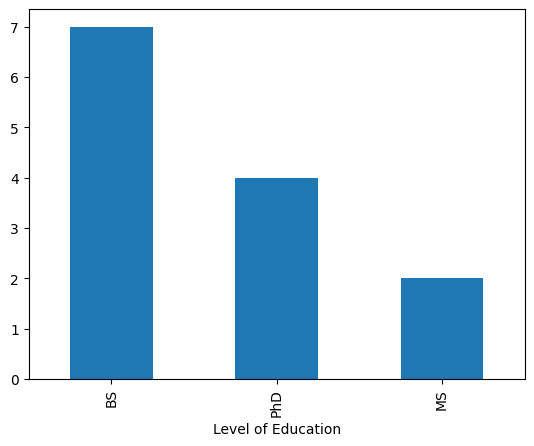

In [23]:
degree_counts.plot(kind='bar')

### Code Explanation
`degree_counts.plot(kind='bar')` creates a bar chart showing how many candidates belong to each education level. This demonstrates Pandas' built in plotting capability.


## Exercise

Try extracting rows 5-10 of our DataFrame, preserving only the "Previous Employers" and "Hired" columns. Assign that to a new DataFrame, and create a histogram plotting the distribution of the previous employers in this subset of the data.

In [24]:
# Exercise solution using the real PastHires.csv data

# Select index labels 5 through 10 inclusive and preserve only the required columns.
new_df = df.loc[5:10, ['Previous employers', 'Hired']]

# Display the resulting DataFrame.
new_df


,Previous employers,Hired
5,0,Y
6,2,Y
7,1,Y
8,5,Y
9,0,N
10,1,N


### Exercise Correction and Explanation
The exercise asks for rows **5 through 10 inclusive** while preserving only `Previous employers` and `Hired`.

The real CSV column is named exactly **`Previous employers`**, with a lowercase `e` in `employers`. Pandas column names are case sensitive, so the code must use the exact spelling from `PastHires.csv`.

The corrected solution uses `df.loc[5:10, ['Previous employers', 'Hired']]`. With `.loc`, both index labels `5` and `10` are included, which makes the requested range explicit and avoids an off by one slicing mistake.

The resulting `Previous employers` values are **0, 2, 1, 5, 0, 1**.


<Axes: title={'center': 'Distribution of Previous Employers for Rows 5 to 10'}, ylabel='Frequency'>

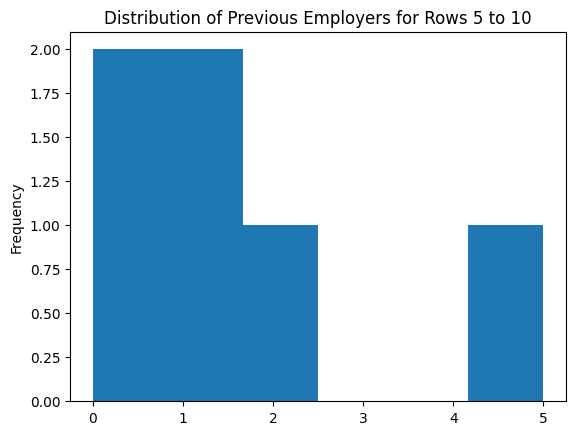

In [26]:
# Plot the distribution of the Previous employers values in the subset.
new_df['Previous employers'].plot(
    kind='hist',
    bins=6,
    title='Distribution of Previous Employers for Rows 5 to 10'
)


### Exercise Histogram Explanation
This cell creates a histogram from the `Previous employers` column in `new_df`.

For rows 5 through 10, the values are **0, 2, 1, 5, 0, 1**. Therefore, `0` occurs twice, `1` occurs twice, `2` occurs once, and `5` occurs once.

The histogram provides a visual summary of that frequency distribution. The code uses the real subset generated from the uploaded `PastHires.csv` file.
